In [7]:
import pandas as pd
import seaborn as sns

In [11]:
benchmark = pd.read_csv("../data/2025-06-25--cargo-bench-kmer-encoding-with-encoding-fn.csv")
benchmark.head()

,benchmark_name,low_ns,avg_ns,high_ns,encoding_type,test_group
0,proteome_index_encode_kmer_protein_5,47.162,47.473,47.791,protein,proteome_index
1,proteome_index_encode_kmer_protein_10,52.064,52.471,52.838,protein,proteome_index
2,proteome_index_encode_kmer_protein_15,56.522,56.924,57.346,protein,proteome_index
3,proteome_index_encode_kmer_protein_20,62.034,62.493,62.989,protein,proteome_index
4,proteome_index_encode_kmer_hp_5,73.148,73.707,74.244,hp,proteome_index


In [12]:
benchmark.benchmark_name.unique()

array(['proteome_index_encode_kmer_protein_5',
       'proteome_index_encode_kmer_protein_10',
       'proteome_index_encode_kmer_protein_15',
       'proteome_index_encode_kmer_protein_20',
       'proteome_index_encode_kmer_hp_5',
       'proteome_index_encode_kmer_hp_10',
       'proteome_index_encode_kmer_hp_15',
       'proteome_index_encode_kmer_hp_20',
       'proteome_index_encode_kmer_dayhoff_5',
       'proteome_index_encode_kmer_dayhoff_10',
       'proteome_index_encode_kmer_dayhoff_15',
       'proteome_index_encode_kmer_dayhoff_20',
       'encodings_encode_kmer_protein_5',
       'encodings_encode_kmer_protein_10',
       'encodings_encode_kmer_protein_15',
       'encodings_encode_kmer_protein_20', 'encodings_encode_kmer_hp_5',
       'encodings_encode_kmer_hp_10', 'encodings_encode_kmer_hp_15',
       'encodings_encode_kmer_hp_20', 'encodings_encode_kmer_dayhoff_5',
       'encodings_encode_kmer_dayhoff_10',
       'encodings_encode_kmer_dayhoff_15',
       'encodings_

In [13]:
benchmark["encoding"] = benchmark.benchmark_name.str.split("_").str[-2]


def get_test_group(benchmark_name):
    if benchmark_name.startswith("proteome_index"):
        return "proteome_index"
    elif "encoding_fn" in benchmark_name:
        return "provide_encoding_fn"
    else:
        return "lookup_encoding_fn_from_moltype"


benchmark["test_group"] = benchmark.benchmark_name.apply(get_test_group)
benchmark["ksize"] = benchmark.benchmark_name.str.split("_").str[-1].astype(int)
benchmark.head()

,benchmark_name,low_ns,avg_ns,high_ns,encoding_type,test_group,encoding,ksize
0,proteome_index_encode_kmer_protein_5,47.162,47.473,47.791,protein,proteome_index,protein,5
1,proteome_index_encode_kmer_protein_10,52.064,52.471,52.838,protein,proteome_index,protein,10
2,proteome_index_encode_kmer_protein_15,56.522,56.924,57.346,protein,proteome_index,protein,15
3,proteome_index_encode_kmer_protein_20,62.034,62.493,62.989,protein,proteome_index,protein,20
4,proteome_index_encode_kmer_hp_5,73.148,73.707,74.244,hp,proteome_index,hp,5


<Axes: xlabel='encoding', ylabel='avg_ns'>

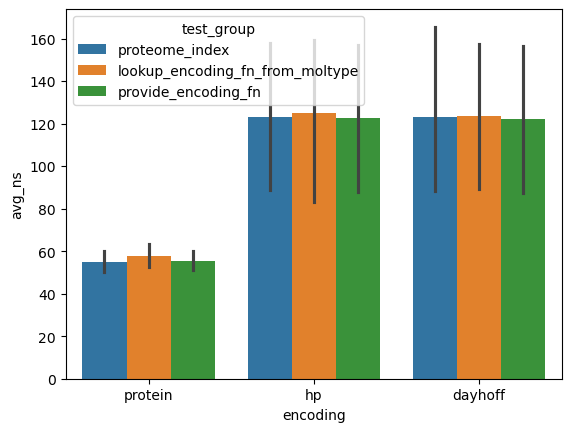

In [14]:
sns.barplot(data=benchmark, x="encoding", y="avg_ns", hue="test_group")